In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as LA

import Hamiltonian as Hamiltonian
import Plotting as plotting
import constants as cst
from pydmd import DMD
from pydmd.preprocessing import hankel_preprocessing

# Error Measurement

# Error as a function of the time delay 

/Users/leomayques/Desktop/semester_VI/BT/scripts/Hamiltonian.py:65: RuntimeWarning: overflow encountered in exp
  time_dynamics = np.array([b * np.exp(omega * T) for T in t]).T
/Users/leomayques/Desktop/semester_VI/BT/scripts/Hamiltonian.py:65: RuntimeWarning: invalid value encountered in multiply
  time_dynamics = np.array([b * np.exp(omega * T) for T in t]).T


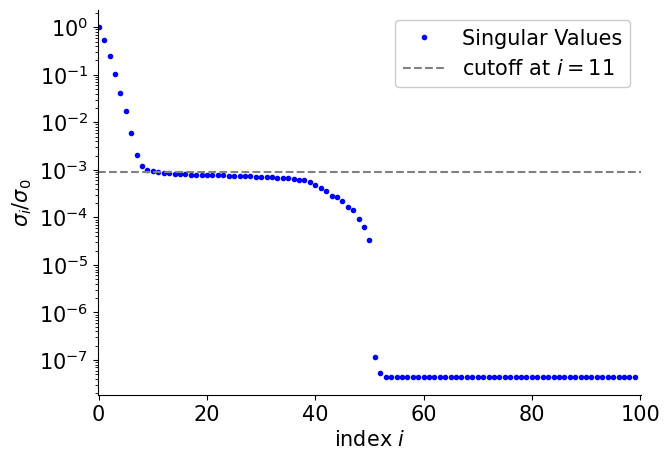

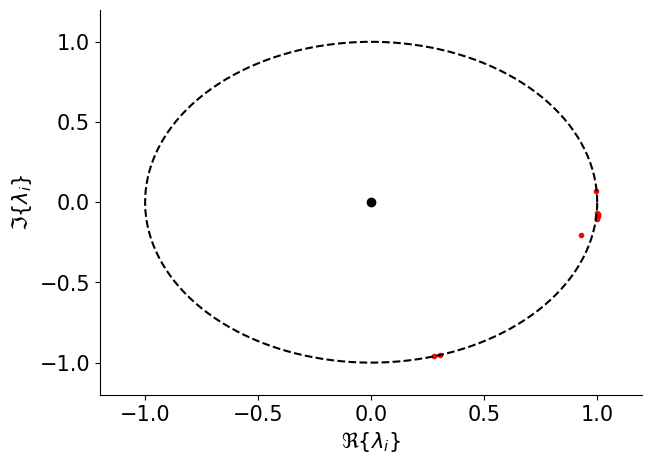

/opt/anaconda3/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 5.3142084176832365e+19. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number inf. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 5029774336.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 726441856.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Inpu

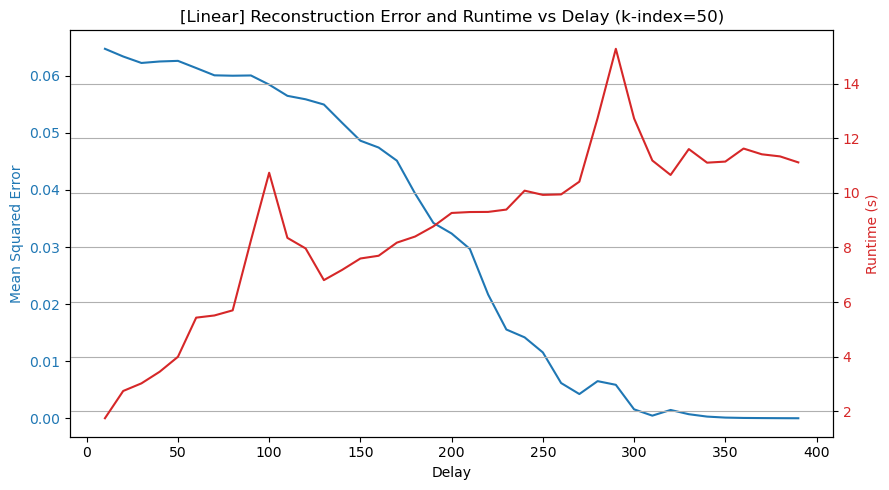

In [6]:

# ====== Set up the simulation ======
#-------------- Envelope Pulse 1 / Band structure 2--------------

case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
t = np.linspace(0, 100, 1000)/ cst.tfs
E0 = 1.2
efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])




solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead




# ========= Apply DMD ===========
rank=11
index=50
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 1  # we will use this number of delays throughout the tutorial    (600)      
dmd = DMD(svd_rank=rank)
delay_dmd = hankel_preprocessing(dmd, d=delay)
delay_dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes

# Chop the first 399 time points to align with DMD output
t_dmd_shifted = t_dmd[:1000-delay] #1000-delay
#t_dmd_shifted = t_dmd[delay-1:] #use this line instead of the line above and DMD will stop working (also reset delay=2)

# Truncate DMD data to match the shortened time axis
x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)] 






#Error calculations
import time
import numpy as np
import matplotlib.pyplot as plt


# Constants
rank = 11
index = 50
max_delay = 40

errors = []
timings = []
delays = [d * 10 for d in range(1, max_delay)]

# Loop over delays
for delay in delays:
    start_time = time.time()

    dmd = DMD(svd_rank=rank)
    delay_dmd = hankel_preprocessing(dmd, d=delay)
    delay_dmd.fit(X)

    elapsed_time = time.time() - start_time
    timings.append(elapsed_time)

    X_dmd = dmd.reconstructed_data.real
    t_dmd_shifted = t_dmd[:1000 - delay]
    x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)]

    original = X[index].real[:len(t_dmd_shifted)]
    mse = np.mean((original - x_dmd_shifted) ** 2)
    errors.append(mse)
    #print(delay)

# === Plot ===
fig1, ax1 = plt.subplots(figsize=(9, 5))

ax1.set_xlabel('Delay')
ax1.set_ylabel('Mean Squared Error', color='tab:blue')
ax1.plot(delays, errors, color='tab:blue', label='MSE')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Runtime (s)', color='tab:red')
ax2.plot(delays, timings, color='tab:red', label='Time')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title(f'[Linear] Reconstruction Error and Runtime vs Delay (k-index={index})')
fig1.tight_layout()
plt.grid(True)
plt.show()





# Error as a function of the truncation rank

/opt/anaconda3/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 54428980.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


rank = 1 elapsed time=  5.526741981506348
rank = 2 elapsed time=  5.707644939422607
rank = 3 elapsed time=  5.994448184967041
rank = 4 elapsed time=  5.726956129074097
rank = 5 elapsed time=  7.282940149307251
rank = 6 elapsed time=  6.287897109985352
rank = 7 elapsed time=  6.121394872665405
rank = 8 elapsed time=  6.064041376113892
rank = 9 elapsed time=  5.978969097137451
rank = 10 elapsed time=  6.014486074447632
rank = 11 elapsed time=  6.030549049377441
rank = 12 elapsed time=  5.98938512802124
rank = 13 elapsed time=  6.119233131408691
rank = 14 elapsed time=  5.991959095001221
rank = 15 elapsed time=  6.032471179962158
rank = 16 elapsed time=  6.007071018218994
rank = 17 elapsed time=  6.03445291519165
rank = 18 elapsed time=  6.105881929397583
rank = 19 elapsed time=  6.033290147781372
rank = 20 elapsed time=  5.968945264816284
rank = 21 elapsed time=  6.190957069396973
rank = 22 elapsed time=  6.013411045074463
rank = 23 elapsed time=  6.096930980682373
rank = 24 elapsed time

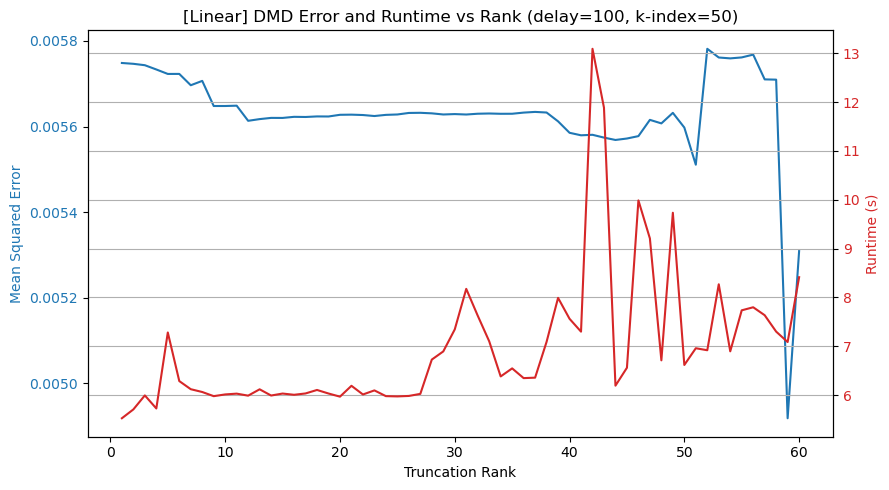

In [7]:
#general imports: 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as LA

import Hamiltonian as Hamiltonian
import Plotting as plotting
import constants as cst


#other imports

import time
import numpy as np
import matplotlib.pyplot as plt
from pydmd import DMD
from pydmd.preprocessing import hankel_preprocessing


# ===================================================== Set up the simulation =====================================================
#-------------- Envelope Pulse 1 / Band structure 2--------------

case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 0.3
t = np.linspace(0, 100, 1000)/ cst.tfs
efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])




solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead






# ===================================================== Apply DMD iteratively =====================================================
# === Setup ===
delay = 100  # fixed delay value
index = 50   # k-index to inspect
max_rank = 60

errors = []
timings = []
ranks = list(range(1, max_rank + 1))

for rank in ranks:
    start_time = time.time()

    dmd = DMD(svd_rank=rank)
    delay_dmd = hankel_preprocessing(dmd, d=delay)
    delay_dmd.fit(X)

    elapsed_time = time.time() - start_time
    timings.append(elapsed_time)

    X_dmd = dmd.reconstructed_data.real
    t_dmd_shifted = t_dmd[:1000 - delay]
    x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)]

    original = X[index].real[:len(t_dmd_shifted)]
    mse = np.mean((original - x_dmd_shifted) ** 2)
    errors.append(mse)
    print("rank =", rank, "elapsed time= ",elapsed_time )



# ===================================================== Plot the results of the iteration (error and time) =====================================================
fig1, ax1 = plt.subplots(figsize=(9, 5))

ax1.set_xlabel('Truncation Rank')
ax1.set_ylabel('Mean Squared Error', color='tab:blue')
ax1.plot(ranks, errors, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Runtime (s)', color='tab:red')
ax2.plot(ranks, timings, color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title(f'[Linear] DMD Error and Runtime vs Rank (delay={delay}, k-index={index})')
fig1.tight_layout()
plt.grid(True)
plt.show()


# 2D Error as a function of time delay and truncation rank: Error(delay, rank)

delay=0, rank=1, error=6.4699e-02, time=0.0795 s
delay=0, rank=6, error=6.4699e-02, time=0.0617 s
delay=0, rank=11, error=6.4699e-02, time=0.0942 s
delay=0, rank=16, error=6.4699e-02, time=0.1057 s
delay=0, rank=21, error=6.4699e-02, time=0.0559 s
delay=0, rank=26, error=6.4699e-02, time=0.0376 s
delay=0, rank=31, error=6.4699e-02, time=0.0484 s
delay=0, rank=36, error=6.4699e-02, time=0.0354 s
delay=40, rank=1, error=6.4698e-02, time=3.9066 s
delay=40, rank=6, error=6.4673e-02, time=3.6548 s
delay=40, rank=11, error=6.4535e-02, time=3.9836 s
delay=40, rank=16, error=6.4407e-02, time=3.9630 s
delay=40, rank=21, error=6.4403e-02, time=4.2567 s
delay=40, rank=26, error=6.4406e-02, time=4.0659 s
delay=40, rank=31, error=6.4419e-02, time=5.3067 s
delay=40, rank=36, error=6.4422e-02, time=4.8007 s
delay=80, rank=1, error=6.4692e-02, time=6.8017 s
delay=80, rank=6, error=6.4553e-02, time=7.6190 s
delay=80, rank=11, error=6.4155e-02, time=5.8858 s
delay=80, rank=16, error=6.4103e-02, time=10.

/opt/anaconda3/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 13942919.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


delay=400, rank=1, error=4.6655e-02, time=12.5147 s
delay=400, rank=6, error=2.9062e-04, time=11.8352 s
delay=400, rank=11, error=9.2493e-06, time=11.7742 s
delay=400, rank=16, error=2.7588e-07, time=11.8871 s
delay=400, rank=21, error=1.3563e-07, time=12.1478 s
delay=400, rank=26, error=1.2866e-07, time=12.5993 s
delay=400, rank=31, error=1.2048e-07, time=14.0035 s
delay=400, rank=36, error=1.1745e-07, time=12.6884 s


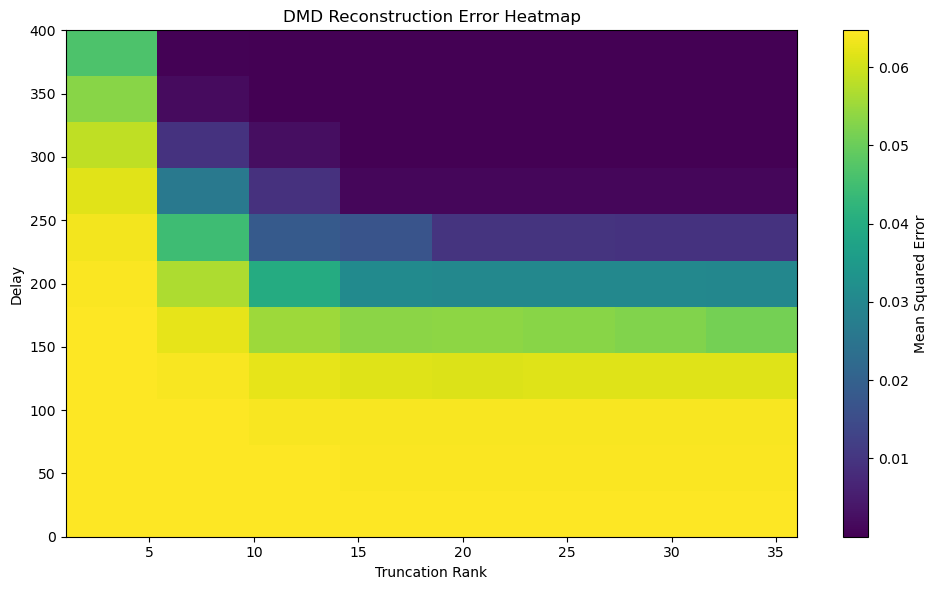

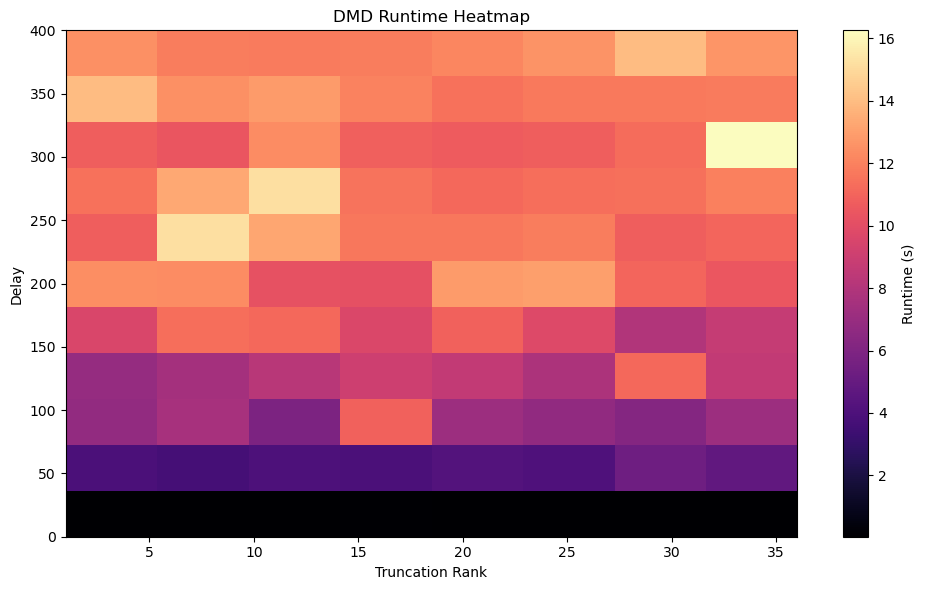

In [8]:
# ====== Imports ======
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time
from pydmd import DMD
from pydmd.preprocessing import hankel_preprocessing

import Hamiltonian as Hamiltonian
import Plotting as plotting
import constants as cst


# ====== Set up the simulation ======
case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM / (2.0 * np.sqrt(2 * np.log(2)))
E0 = 1.2
t = np.linspace(0, 100, 1000) / cst.tfs
efield_case1 = Hamiltonian.E(t, sigma, E0, ω=0.5 / cst.Ry, case=case)
J = 1.0 / cst.Ry
delta = 0.5 / cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]
t_span = (t[0], t[-1])

solutions = np.zeros((len(k_list), 2, len(t)), dtype=np.complex64)
for k_i, k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5 / cst.Ry, case=case),
                    t_span, y0, t_eval=t)
    solutions[k_i, 0, :] = sol.y[2]
    solutions[k_i, 1, :] = sol.y[3]

t_dmd = t[:-1]
X = solutions[:, 0, :-1]
index = 50  # k-index to evaluate

# ====== Set up the nested sweep ======
delay_values = list(range(0, 401, 40))
rank_values = list(range(1, 41, 5))

errors_grid = np.zeros((len(delay_values), len(rank_values)))
timings_grid = np.zeros((len(delay_values), len(rank_values)))

for i, delay in enumerate(delay_values):
    for j, rank in enumerate(rank_values):
        start = time.time()

        dmd = DMD(svd_rank=rank)
        if delay > 0:
            dmd = hankel_preprocessing(dmd, d=delay)
        dmd.fit(X)

        elapsed = time.time() - start
        timings_grid[i, j] = elapsed

        X_dmd = dmd.reconstructed_data.real
        t_dmd_shifted = t_dmd[:X_dmd.shape[1]]
        x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)]
        original = X[index].real[:len(t_dmd_shifted)]
        mse = np.mean((original - x_dmd_shifted) ** 2)
        errors_grid[i, j] = mse

        print(f"delay={delay}, rank={rank}, error={mse:.4e}, time={elapsed:.4f} s")


# ====== Plot error heatmap ======
plt.figure(figsize=(10, 6))
plt.imshow(errors_grid, aspect='auto', origin='lower',
           extent=[min(rank_values), max(rank_values), min(delay_values), max(delay_values)],
           cmap='viridis')
plt.colorbar(label='Mean Squared Error')
plt.xlabel('Truncation Rank')
plt.ylabel('Delay')
plt.title('DMD Reconstruction Error Heatmap')
plt.tight_layout()
plt.show()

# ====== Plot runtime heatmap ======
plt.figure(figsize=(10, 6))
plt.imshow(timings_grid, aspect='auto', origin='lower',
           extent=[min(rank_values), max(rank_values), min(delay_values), max(delay_values)],
           cmap='magma')
plt.colorbar(label='Runtime (s)')
plt.xlabel('Truncation Rank')
plt.ylabel('Delay')
plt.title('DMD Runtime Heatmap')
plt.tight_layout()
plt.show()